In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('salary_dataset.csv')

In [3]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [5]:
df.shape

(30, 3)

In [6]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [7]:
import matplotlib.pyplot as plt

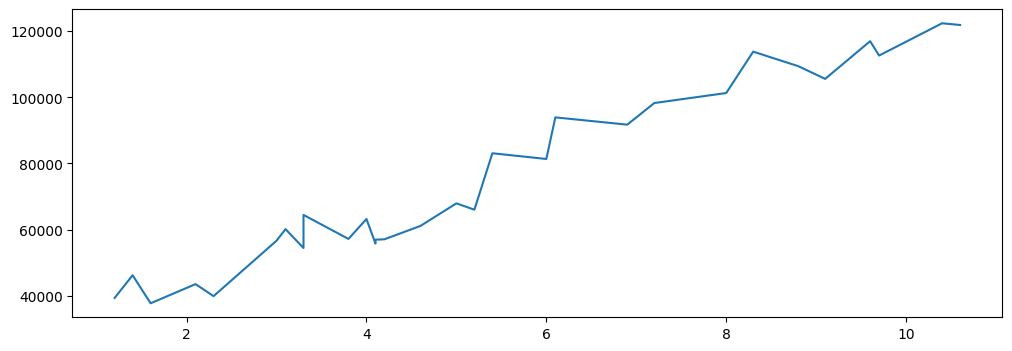

In [8]:
fig,ax=plt.subplots(figsize=(12,4))
ax.plot(df['YearsExperience'],df['Salary'])
plt.show()


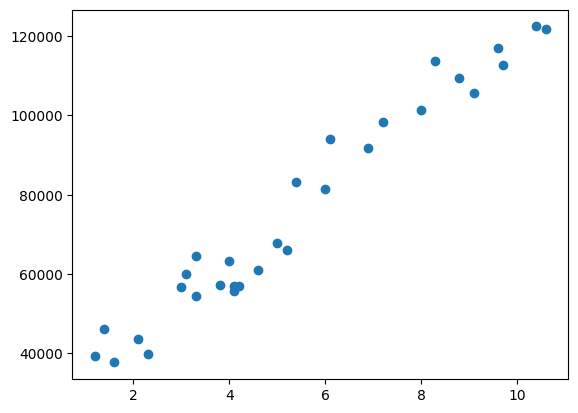

In [9]:
plt.scatter(df['YearsExperience'],df['Salary'])
plt.show()

In [10]:
df.corr()

,Unnamed: 0,YearsExperience,Salary
Unnamed: 0,1.000000,0.986460,0.960826
YearsExperience,0.986460,1.000000,0.978242
Salary,0.960826,0.978242,1.000000


In [11]:
import numpy as np
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower)
print(upper)


-9014.25
166281.75


In [12]:
X=df[['YearsExperience']]
y=df['Salary']
X.shape
y.shape

(30,)

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
import numpy as np
from sklearn.metrics import mean_squared_error , r2_score
y_pred=model.predict(X_test)
rmse=np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [16]:
print(rmse)
print(r2)

7059.043621901506
0.9024461774180498


In [71]:
model.intercept_


np.float64(26437.67801193487)

In [72]:
model.coef_

array([   0.        , 8481.84129267,   80.62084747])

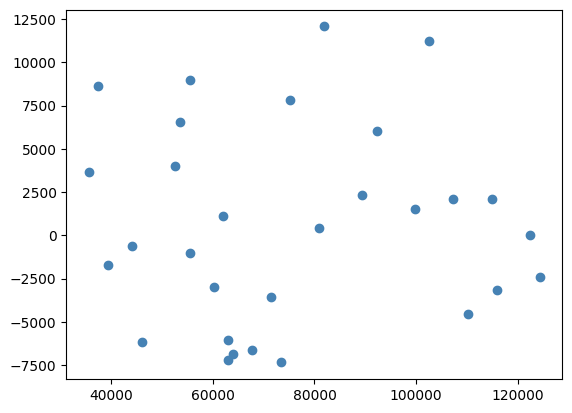

In [19]:
y_pred_all = model.predict(X)
residuals = y - y_pred_all
plt.scatter(y_pred_all, residuals, color='steelblue')

(array([6., 2., 4., 3., 6., 2., 1., 2., 2., 2.]),
 array([-7354.04115923, -5411.08453831, -3468.12791738, -1525.17129645,
          417.78532447,  2360.7419454 ,  4303.69856633,  6246.65518726,
         8189.61180818, 10132.56842911, 12075.52505004]),
 <BarContainer object of 10 artists>)

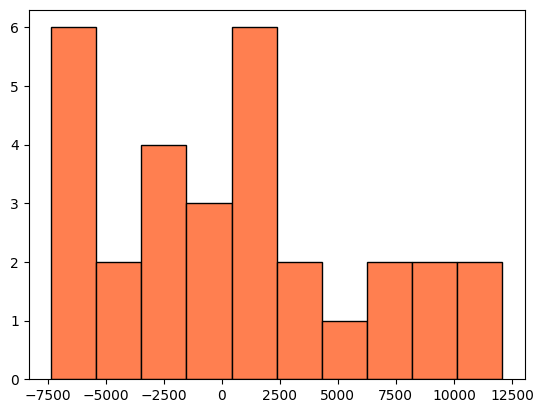

In [20]:
plt.hist(residuals, bins=10, color='coral', edgecolor='black')

In [21]:
residual=y_test-y_pred

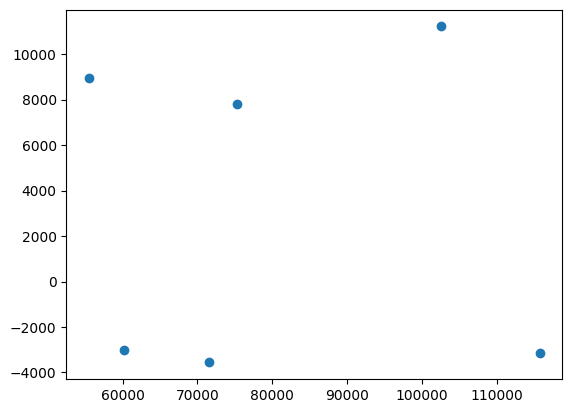

In [22]:
plt.scatter(y_pred,residual)

In [23]:
residuals.mean()

np.float64(609.5449051852738)

In [24]:
residual.mean()

np.float64(3047.724525926345)

In [28]:
from sklearn.model_selection import cross_val_score, KFold
kf=KFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(model,X,y,cv=kf)


In [30]:
print(scores)
print(np.mean(scores))
print(np.std(scores))

[0.90244618 0.96846325 0.91621488 0.98161851 0.84333552]
0.922415665403513
0.04963115265341952


In [61]:
#from sklearn.preprocessing import PolynomialFeatures
#poly=PolynomialFeatures(degree=2)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)
#model_poly=LinearRegression()
model_poly.fit(X_train_poly,y_train)
y_pred_poly=model_poly.predict(X_test_poly)
rmse_poly=np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2 = r2_score(y_test, y_pred_poly)
print(rmse)
print(r2)



7059.043621901506
0.8971645780890873


In [62]:
X_range=pd.DataFrame(np.linspace(X.min(),X.max(),100),columns=['YearsExperience'])
X_range_poly=poly.transform(X_range)

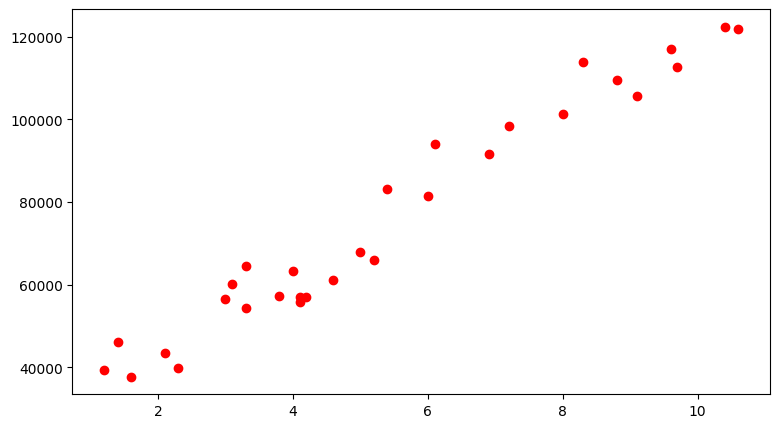

In [63]:
plt.figure(figsize=(9,5))
plt.scatter(X,y,color='red', label='Actual')

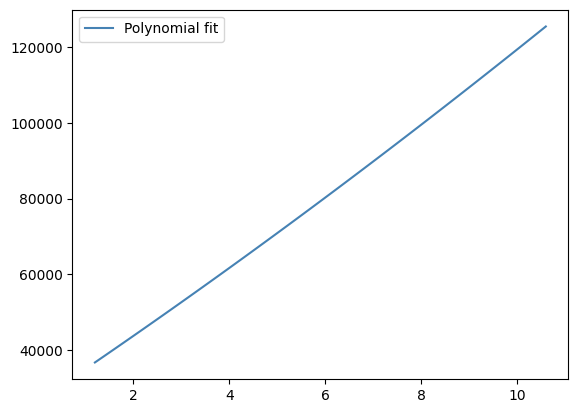

In [64]:
plt.plot(X_range, model_poly.predict(X_range_poly), 
         color='steelblue', label='Polynomial fit')
plt.legend()
plt.show()

In [66]:
import joblib
joblib.dump(model,'salary_model.pkl')
print('model saved')

model saved


In [67]:
loaded_model=joblib.load('salary_model.pkl')

In [69]:
print(loaded_model.coef_)

[   0.         8481.84129267   80.62084747]
